# 02 · Kleine Datensätze, Overfitting & Augmentierung – Olivetti Faces

Aufbauend auf dem ersten CNN-Notebook wechseln wir das Motiv: statt Ziffern jetzt
**Gesichter**. Der `fetch_olivetti_faces`-Datensatz (AT&T Cambridge, 1992–94) enthält
**400 Graustufenbilder zu je 64×64 Pixeln** von **40 Personen** – also nur
**10 Aufnahmen pro Person**. Genau diese Knappheit macht ihn lehrreich.

Das Notebook ist in **zwei Blöcke** geteilt:

> **Block 1 – Das Problem sichtbar machen.** Wir trainieren ein CNN mit sehr wenigen
> Bildern pro Person und beobachten **Overfitting**: Das Netz lernt die
> Trainingsbilder auswendig (Train-Genauigkeit ≈ 100 %), versagt aber auf
> ungesehenen Bildern deutlich stärker.
>
> **Block 2 – Das Mittel.** Wir stocken den Trainingsbestand durch
> **Datenaugmentierung** auf (Spiegeln, leichtes Drehen/Verschieben, Helligkeit) und
> trainieren dasselbe Netz erneut. Die Lücke zwischen Training und Validierung wird
> kleiner.

Beide Blöcke sind **bis auf die Augmentierung identisch** – gleiche Architektur,
gleiche Startgewichte, gleiche Epochen. Nur so ist der Vergleich fair.

In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from torchvision.transforms import v2

torch.manual_seed(42)
np.random.seed(42)

# Haus-Stil (LFB KI BW)
DUNKELBLAU = "#1B3A5C"
MITTELBLAU = "#2E75B6"
ROT        = "#C0392B"
plt.rcParams["font.family"]     = "DejaVu Sans"   # Arial-nah
plt.rcParams["axes.titlecolor"] = DUNKELBLAU
plt.rcParams["figure.dpi"]      = 110

## Daten laden und ansehen

`fetch_olivetti_faces()` lädt den Datensatz beim ersten Aufruf herunter und legt ihn
lokal ab. Die Pixel sind **bereits auf 0–1 normiert** – die Division durch einen
Maximalwert wie bei den Digits entfällt hier also.

Bilder gesamt: 400  | Format: (1, 64, 64) (Kanal, H, B)
Personen (Klassen): 40  | Bilder pro Person: 10
Pixelwerte: min=0.00  max=1.00  (schon normiert)


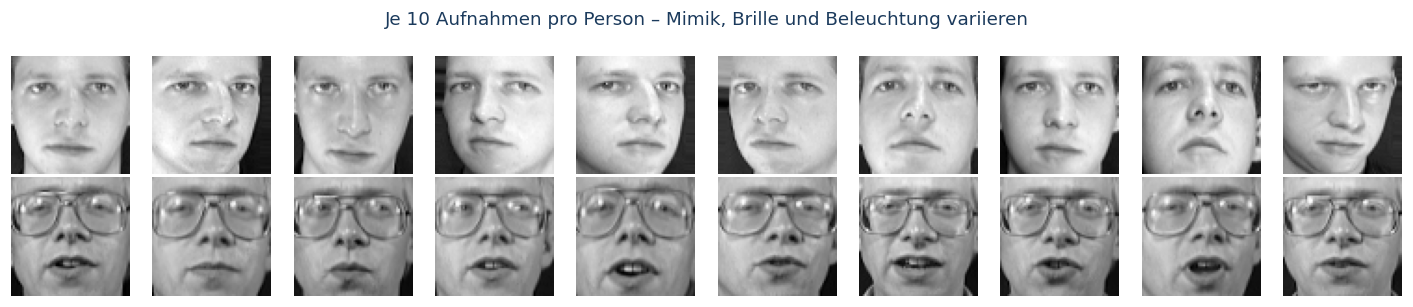

In [2]:
daten = fetch_olivetti_faces(shuffle=False)
X = torch.tensor(daten.images, dtype=torch.float32).unsqueeze(1)  # (400, 1, 64, 64)
y = torch.tensor(daten.target, dtype=torch.long)                  # Person 0..39

print(f"Bilder gesamt: {X.shape[0]}  | Format: {tuple(X.shape[1:])} (Kanal, H, B)")
print(f"Personen (Klassen): {len(torch.unique(y))}  | Bilder pro Person: 10")
print(f"Pixelwerte: min={X.min():.2f}  max={X.max():.2f}  (schon normiert)")

# Je eine Reihe (= 10 Aufnahmen) der ersten zwei Personen zeigen
fig, axs = plt.subplots(2, 10, figsize=(13, 2.8))
for person in range(2):
    for bild in range(10):
        idx = person * 10 + bild
        axs[person, bild].imshow(X[idx, 0], cmap="gray")
        axs[person, bild].axis("off")
    axs[person, 0].set_ylabel(f"Person {person}", rotation=0, labelpad=28,
                              color=DUNKELBLAU, va="center")
fig.suptitle("Je 10 Aufnahmen pro Person – Mimik, Brille und Beleuchtung variieren",
             color=DUNKELBLAU)
plt.tight_layout(); plt.show()

## Datenaufteilung – bewusst sehr wenig Training

Bei nur 10 Bildern pro Person müssen wir **stratifiziert** aufteilen (`stratify=y`),
damit in jeder Teilmenge **jede** Person vorkommt. Wir wählen absichtlich ein
knappes Trainingsbudget – **4 Bilder zum Trainieren, je 3 zur Validierung und zum
Test pro Person** –, damit Overfitting in Block 1 klar zutage tritt.

In [3]:
# test = 3/Person (30 %), danach val = 3/Person, train = 4/Person
X_rest, X_test, y_rest, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_rest, y_rest, test_size=3/7, stratify=y_rest, random_state=42)

print(f"Training:    {len(X_train):3d} Bilder  (4 pro Person)")
print(f"Validierung: {len(X_val):3d} Bilder  (3 pro Person)")
print(f"Test:        {len(X_test):3d} Bilder  (3 pro Person)")

Training:    160 Bilder  (4 pro Person)
Validierung: 120 Bilder  (3 pro Person)
Test:        120 Bilder  (3 pro Person)


## Bausteine, die beide Blöcke gemeinsam nutzen

Damit der Vergleich fair ist, definieren wir das Modell, die Trainingsfunktion und
die Auswertung **einmal** und verwenden sie in beiden Blöcken. `baue_modell()` setzt
intern denselben Seed – so starten beide Netze mit **identischen Anfangsgewichten**.

Wichtig: Die Trainings-*Schritte* laufen über den jeweiligen `DataLoader` (in Block 2
augmentiert), aber Train- und Val-Kennzahlen werden in **jeder Epoche auf den
sauberen, unveränderten Bildern** gemessen – sonst wären die Kurven nicht
vergleichbar.

In [4]:
def baue_modell():
    # gleicher Seed -> in beiden Blöcken identische Startgewichte
    torch.manual_seed(42)
    return nn.Sequential(
        nn.Conv2d(1,  8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 64 -> 32
        nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 32 -> 16
        nn.Conv2d(16,32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 16 ->  8
        nn.Flatten(),
        nn.Linear(32*8*8, 64), nn.ReLU(),
        nn.Linear(64, 40),
    )

def genauigkeit(modell, Xd, yd):
    modell.eval()
    with torch.no_grad():
        return (modell(Xd).argmax(1) == yd).float().mean().item()

def trainiere(modell, loader, epochs=80):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(modell.parameters(), lr=1e-3)
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(epochs):
        modell.train()
        for xb, yb in loader:                 # Gradientenschritte über den DataLoader
            optimizer.zero_grad()
            loss = criterion(modell(xb), yb)
            loss.backward()
            optimizer.step()
        # Auswertung auf den SAUBEREN Daten (für vergleichbare Kurven)
        modell.eval()
        with torch.no_grad():
            hist["train_loss"].append(criterion(modell(X_train), y_train).item())
            hist["val_loss"].append(criterion(modell(X_val),   y_val).item())
            hist["train_acc"].append((modell(X_train).argmax(1) == y_train).float().mean().item())
            hist["val_acc"].append((modell(X_val).argmax(1)   == y_val).float().mean().item())
    return hist

def zeige_verlauf(hist, titel):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
    a1.plot(hist["train_loss"], color=MITTELBLAU, label="Train")
    a1.plot(hist["val_loss"],   color=ROT,        label="Validierung")
    a1.set_title("Loss"); a1.set_xlabel("Epoche"); a1.legend()
    a2.plot(hist["train_acc"], color=MITTELBLAU, label="Train")
    a2.plot(hist["val_acc"],   color=ROT,        label="Validierung")
    a2.set_title("Genauigkeit"); a2.set_xlabel("Epoche"); a2.set_ylim(0, 1.02); a2.legend()
    fig.suptitle(titel, color=DUNKELBLAU)
    plt.tight_layout(); plt.show()

anzahl_params = sum(p.numel() for p in baue_modell().parameters() if p.requires_grad)
print(f"Trainierbare Parameter des Modells: {anzahl_params:,}")

Trainierbare Parameter des Modells: 139,624


# Block 1 · Das Problem: Overfitting

Wir trainieren **ohne** Augmentierung – das Netz sieht in jeder Epoche genau dieselben
160 Trainingsbilder. Achtet beim Ergebnis auf zwei Dinge:

1. die **Loss-Kurven**: Der Train-Loss fällt gegen 0, während der Val-Loss ab einem
   gewissen Punkt wieder **ansteigt** – das ist die Signatur von Overfitting.
2. die **Lücke** zwischen Train- und Val-Genauigkeit am Ende.

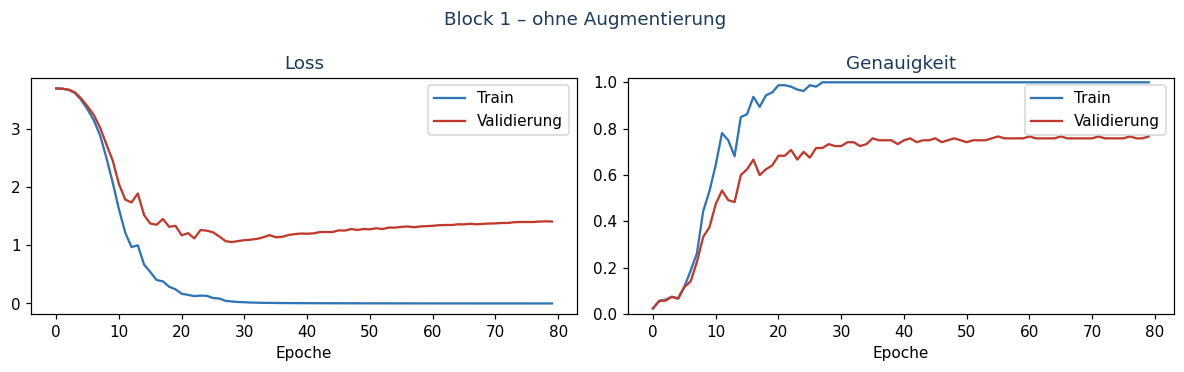

Train-Genauigkeit: 100.0%
Val-Genauigkeit:    76.7%
Test-Genauigkeit:   80.0%
--> Lücke Train-Val: 23.3 Prozentpunkte
--> bester Val-Loss bei Epoche 28, danach steigt er wieder (Overfitting)


In [5]:
loader_ohne = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_train, y_train),
    batch_size=16, shuffle=True)

modell1 = baue_modell()
hist1 = trainiere(modell1, loader_ohne, epochs=80)
zeige_verlauf(hist1, "Block 1 – ohne Augmentierung")

train_acc1 = genauigkeit(modell1, X_train, y_train)
val_acc1   = genauigkeit(modell1, X_val,   y_val)
test_acc1  = genauigkeit(modell1, X_test,  y_test)
print(f"Train-Genauigkeit: {train_acc1*100:5.1f}%")
print(f"Val-Genauigkeit:   {val_acc1*100:5.1f}%")
print(f"Test-Genauigkeit:  {test_acc1*100:5.1f}%")
print(f"--> Lücke Train-Val: {(train_acc1-val_acc1)*100:.1f} Prozentpunkte")
bestes_epoch = int(np.argmin(hist1['val_loss']))
print(f"--> bester Val-Loss bei Epoche {bestes_epoch}, danach steigt er wieder (Overfitting)")

**Deutung.** Das Netz hat genug Kapazität, die 160 Trainingsbilder *auswendig* zu
lernen (Train-Genauigkeit ≈ 100 %). Auf neuen Bildern fehlt ihm aber die
Verallgemeinerung. Der wiedersteigende Val-Loss zeigt zusätzlich: Das Netz wird auf
den Validierungsbildern nicht nur nicht besser, sondern in seinen Fehlern sogar
*selbstsicherer*. Ursache ist schlicht **zu wenig Variation in den Trainingsdaten**.

# Block 2 · Das Mittel: Datenaugmentierung

**Idee:** Wir erzeugen aus jedem Trainingsbild bei jedem Durchlauf leicht
veränderte Varianten – gespiegelt, etwas gedreht/verschoben, heller oder dunkler.
So „sieht" das Netz pro Epoche andere Bilder und kann sie nicht mehr auswendig
lernen. Drei Punkte sind didaktisch wichtig:

- **On-the-fly:** Die Veränderung passiert in jeder Epoche neu – der Datensatz wird
  dadurch effektiv viel größer, ohne dass wir neue Bilder speichern.
- **Nur auf den Trainingsdaten:** Validierung und Test bleiben unverändert, sonst
  würden wir uns selbst betrügen.
- **Nur sinnvolle Transformationen:** Ein **horizontales** Spiegeln ist bei Gesichtern
  erlaubt (Gesichter sind grob symmetrisch). Ein **vertikales** Spiegeln wäre
  *falsch* – ein auf dem Kopf stehendes Gesicht ist kein realistisches Bild dieser
  Person. Augmentierung muss immer zur Domäne passen.

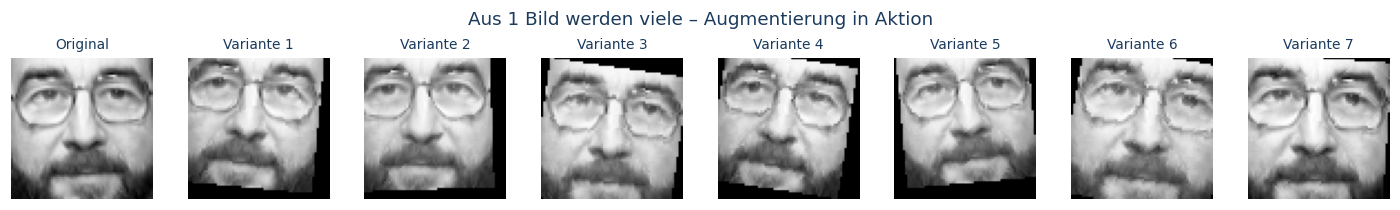

In [6]:
augmentierung = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),                                  # links/rechts spiegeln
    v2.RandomAffine(degrees=10, translate=(0.08, 0.08),             # leicht drehen/verschieben
                    scale=(0.9, 1.1)),                              # leicht zoomen
    v2.ColorJitter(brightness=0.2, contrast=0.2),                  # Helligkeit/Kontrast
    # KEIN v2.RandomVerticalFlip -> Gesicht auf dem Kopf ist unrealistisch!
])

# Sichtbar machen, was die Augmentierung tut: ein Bild, acht zufällige Varianten
torch.manual_seed(0)
beispiel = X_train[0]
fig, axs = plt.subplots(1, 8, figsize=(13, 1.9))
axs[0].imshow(beispiel[0], cmap="gray"); axs[0].set_title("Original", fontsize=9); axs[0].axis("off")
for i in range(1, 8):
    axs[i].imshow(augmentierung(beispiel)[0], cmap="gray")
    axs[i].set_title(f"Variante {i}", fontsize=9); axs[i].axis("off")
fig.suptitle("Aus 1 Bild werden viele – Augmentierung in Aktion", color=DUNKELBLAU)
plt.tight_layout(); plt.show()

Jetzt trainieren wir **dasselbe Netz** (gleiche Startgewichte) erneut – diesmal mit
einem `Dataset`, das die Augmentierung bei jedem Zugriff anwendet.

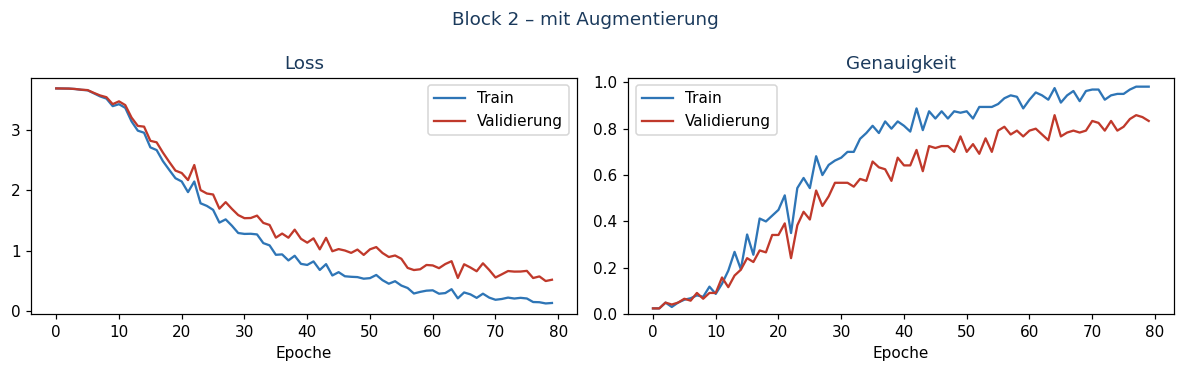

Train-Genauigkeit:  98.1%
Val-Genauigkeit:    83.3%
Test-Genauigkeit:   81.7%
--> Lücke Train-Val: 14.8 Prozentpunkte


In [7]:
class AugmentiertesDataset(torch.utils.data.Dataset):
    def __init__(self, bilder, labels, transform):
        self.bilder = bilder; self.labels = labels; self.transform = transform
    def __len__(self):
        return len(self.bilder)
    def __getitem__(self, i):
        return self.transform(self.bilder[i]), self.labels[i]   # bei jedem Zugriff neu augmentiert

loader_mit = torch.utils.data.DataLoader(
    AugmentiertesDataset(X_train, y_train, augmentierung),
    batch_size=16, shuffle=True)

modell2 = baue_modell()                 # identische Startgewichte wie Block 1
hist2 = trainiere(modell2, loader_mit, epochs=80)
zeige_verlauf(hist2, "Block 2 – mit Augmentierung")

train_acc2 = genauigkeit(modell2, X_train, y_train)
val_acc2   = genauigkeit(modell2, X_val,   y_val)
test_acc2  = genauigkeit(modell2, X_test,  y_test)
print(f"Train-Genauigkeit: {train_acc2*100:5.1f}%")
print(f"Val-Genauigkeit:   {val_acc2*100:5.1f}%")
print(f"Test-Genauigkeit:  {test_acc2*100:5.1f}%")
print(f"--> Lücke Train-Val: {(train_acc2-val_acc2)*100:.1f} Prozentpunkte")

# Vergleich beider Blöcke

Am aussagekräftigsten ist die **Lücke zwischen Training und Validierung**: Je kleiner
sie ist, desto besser verallgemeinert das Netz. Und der **Val-Loss** zeigt, ob das
Training „aus dem Ruder läuft".

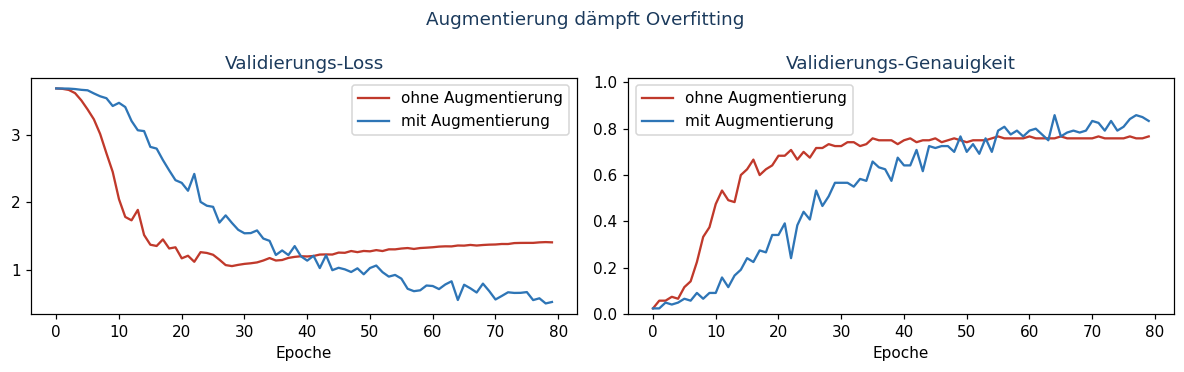

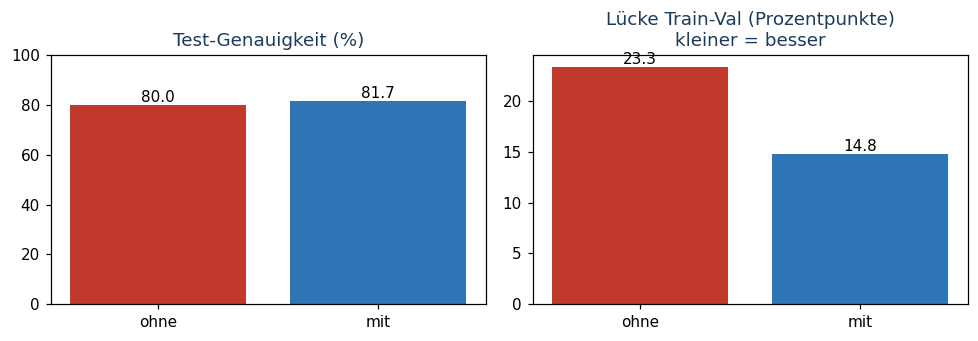

                         ohne Aug.    mit Aug.
----------------------------------------------
Test-Genauigkeit             80.0%       81.7%
Lücke Train-Val (pp)          23.3        14.8
finaler Val-Loss             1.406       0.521


In [8]:
# Val-Loss und Val-Genauigkeit beider Blöcke übereinanderlegen
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.plot(hist1["val_loss"], color=ROT,        label="ohne Augmentierung")
a1.plot(hist2["val_loss"], color=MITTELBLAU, label="mit Augmentierung")
a1.set_title("Validierungs-Loss"); a1.set_xlabel("Epoche"); a1.legend()
a2.plot(hist1["val_acc"], color=ROT,        label="ohne Augmentierung")
a2.plot(hist2["val_acc"], color=MITTELBLAU, label="mit Augmentierung")
a2.set_title("Validierungs-Genauigkeit"); a2.set_xlabel("Epoche"); a2.set_ylim(0, 1.02); a2.legend()
fig.suptitle("Augmentierung dämpft Overfitting", color=DUNKELBLAU)
plt.tight_layout(); plt.show()

# Balkenvergleich: Test-Genauigkeit und Train-Val-Lücke
luecke1, luecke2 = (train_acc1-val_acc1)*100, (train_acc2-val_acc2)*100
fig, (b1, b2) = plt.subplots(1, 2, figsize=(9, 3.2))
b1.bar(["ohne", "mit"], [test_acc1*100, test_acc2*100], color=[ROT, MITTELBLAU])
b1.set_title("Test-Genauigkeit (%)"); b1.set_ylim(0, 100)
for i, v in enumerate([test_acc1*100, test_acc2*100]): b1.text(i, v+1, f"{v:.1f}", ha="center")
b2.bar(["ohne", "mit"], [luecke1, luecke2], color=[ROT, MITTELBLAU])
b2.set_title("Lücke Train-Val (Prozentpunkte)\nkleiner = besser")
for i, v in enumerate([luecke1, luecke2]): b2.text(i, v+0.3, f"{v:.1f}", ha="center")
plt.tight_layout(); plt.show()

print(f"{'':22}{'ohne Aug.':>12}{'mit Aug.':>12}")
print("-"*46)
print(f"{'Test-Genauigkeit':22}{test_acc1*100:>11.1f}%{test_acc2*100:>11.1f}%")
print(f"{'Lücke Train-Val (pp)':22}{luecke1:>12.1f}{luecke2:>12.1f}")
print(f"{'finaler Val-Loss':22}{hist1['val_loss'][-1]:>12.3f}{hist2['val_loss'][-1]:>12.3f}")

## Fazit & Einordnung

- **Block 1** zeigt Overfitting als messbares Phänomen: perfekte Trainings-, aber
  schwächere Validierungs-/Testleistung und ein wiedersteigender Val-Loss.
- **Block 2** verkleinert die Lücke und senkt den Val-Loss deutlich – allein dadurch,
  dass aus wenigen Bildern „on the fly" viele Varianten werden.

**Wichtig zur Ehrlichkeit:** Augmentierung ist kein Allheilmittel. Sie wirkt nur mit
**domänen-passenden** Transformationen (bei Gesichtern: spiegeln ja, auf den Kopf
stellen nein) und ergänzt andere Mittel gegen Overfitting wie **Early Stopping**,
**Weight Decay** oder **Dropout** – sie ersetzt sie nicht.

**Zum Weiterexperimentieren:** das Trainingsbudget noch kleiner wählen (2 statt 4
Bilder/Person), einzelne Transformationen weglassen und beobachten, welche am meisten
bringt, oder testweise das (verbotene) vertikale Spiegeln hinzunehmen und sehen, wie
es schadet.